# Model Lab 1: เทียบโมเดล — Saphondanai

**คำถาม:** มีโมเดลไหน "ฉลาดกว่า" XGBoost ตัวปัจจุบันไหม วัดด้วย **F1** (ตอนนี้ test F1 = 0.488 ที่ threshold 0.5)

**กติกาการทดลอง (ให้ทุกโมเดลแข่งกันแบบยุติธรรม):**

| เรื่อง | วิธี | เหตุผล |
| :--- | :--- | :--- |
| ข้อมูล | ฟีเจอร์ 50 ตัวชุดเดียวกับโมเดลเดิม, split 80/20 seed 42 | เทียบกับโมเดลเดิมได้ตรง ๆ |
| ข้อมูลไม่สมดุล (ลาออก 16%) | ใส่ class weight + **จูน threshold** | threshold 0.5 ไม่ได้ดีที่สุดเสมอไป เมื่อคนลาออกมีน้อย จุดตัดที่ให้ F1 สูงสุดมักต่างจาก 0.5 |
| การจูน | Optuna 30 trials ต่อโมเดล เท่ากันทุกตัว | โมเดลที่ถูกจูนมากกว่าจะได้เปรียบ ถ้าจำนวนรอบไม่เท่ากัน |
| คะแนนตอนจูน | F1 ที่ threshold ดีที่สุด จาก out-of-fold (CV 5 fold × 2 รอบ) บน train | ตรงกับเป้าหมาย F1 และไม่แตะ test |
| สเกลข้อมูล | LR, SVM, KNN, MLP ใส่ `StandardScaler` ใน Pipeline | โมเดลกลุ่มนี้คิดจากระยะทาง/น้ำหนัก ถ้าไม่สเกล ฟีเจอร์ค่าใหญ่ (เงินเดือน) จะกลบฟีเจอร์ค่าเล็ก scaler อยู่ใน Pipeline จึง fit ใหม่ทุก fold ไม่รั่วข้อมูล |
| test set | ใช้ครั้งเดียวตอนจบ threshold ตรึงจาก train | ถ้าเลือกอะไรจาก test คะแนนจะดูดีเกินจริง |

**Out-of-fold (OOF) คืออะไร:** แบ่ง train เป็น 5 ส่วน เทรนบน 4 ส่วนแล้วทายส่วนที่เหลือ วนจนทุกคนถูกทายโดยโมเดลที่ไม่เคยเห็นตัวเขา ได้คะแนนความเสี่ยง "ที่ไม่โกง" ของพนักงานทุกคนใน train ใช้หา threshold ได้โดยไม่ต้องแตะ test

In [1]:
import sys, json, subprocess, time, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt, mlflow, numpy as np, optuna, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

import mlflow_setup
from clean_pipeline import RAW_FILENAME, clean_data, load_raw_data
from feature_pipeline import SELECTED_FEATURES, add_features

optuna.logging.set_verbosity(optuna.logging.WARNING)
OUT = "../docs/model_lab_S"
import os; os.makedirs(OUT, exist_ok=True)

df = add_features(clean_data(load_raw_data(f"../data/raw/{RAW_FILENAME}")), only=SELECTED_FEATURES)
X, y = df.drop(columns="Attrition"), df["Attrition"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
SPW = (ytr == 0).sum() / (ytr == 1).sum()
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
N_TRIALS = 30

# สีตาม palette ที่ผ่านการตรวจ colorblind แล้ว (dataviz reference palette) + ฟอนต์ที่มีภาษาไทย
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "muted": "#898781", "grid": "#e1e0d9", "ink": "#0b0b0b", "ink2": "#52514e"}
plt.rcParams.update({"font.family": ["Tahoma"], "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C["ink2"],
                     "xtick.color": C["ink2"], "ytick.color": C["ink2"], "axes.grid": True, "grid.color": C["grid"],
                     "axes.spines.top": False, "axes.axisbelow": True, "axes.spines.right": False, "figure.dpi": 110, "savefig.bbox": "tight"})
print("train", Xtr.shape, "test", Xte.shape, "| ลาออกใน train", round(ytr.mean(), 3), "| scale_pos_weight", round(SPW, 2))

train (1176, 50) test (294, 50) | ลาออกใน train 0.162 | scale_pos_weight 5.19


## 1. เครื่องมือวัดผล

- `best_threshold` หา threshold ที่ให้ F1 สูงสุดจาก precision-recall curve
- `cv_eval` เทรนแบบ OOF แล้วคืนค่า:
  - F1 เฉลี่ยและ SD ของ 10 fold ที่ threshold นั้น (SD บอกว่าคะแนนแกว่งแค่ไหน ใช้ตัดสินว่าต่างกันจริงหรือแค่บังเอิญ)
  - PR-AUC

In [2]:
def best_threshold(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    i = int(np.argmax(f1[:-1]))  # ตัวสุดท้ายของ curve ไม่มี threshold
    return float(thr[i])

def cv_eval(model, X=Xtr, y=ytr):
    y = y.to_numpy()
    reps, folds, p = [], [], np.zeros(len(y))
    for i, (tr, va) in enumerate(CV.split(X, y)):
        m = clone(model).fit(X.iloc[tr], y[tr])
        p[va] = m.predict_proba(X.iloc[va])[:, 1]
        folds.append((len(reps), va))
        if (i + 1) % 5 == 0:
            reps.append(p.copy()); p = np.zeros(len(y))
    thr = best_threshold(np.tile(y, len(reps)), np.concatenate(reps))
    fold_f1 = [f1_score(y[va], reps[r][va] >= thr) for r, va in folds]
    return {"f1": float(np.mean(fold_f1)), "f1_sd": float(np.std(fold_f1, ddof=1)), "fold_f1": fold_f1,
            "threshold": thr, "pr_auc": float(np.mean([average_precision_score(y, r) for r in reps])),
            "f1_at_05": float(np.mean([f1_score(y[va], reps[r][va] >= 0.5) for r, va in folds])),
            "oof": reps[0]}

## 2. โมเดลและช่วงค่าที่ให้ Optuna ค้น

| โมเดล | แนวคิด | จัดการข้อมูลไม่สมดุล |
| :--- | :--- | :--- |
| Logistic Regression | เส้นตรงถ่วงน้ำหนักฟีเจอร์ ง่ายสุด อธิบายง่าย | `class_weight="balanced"` |
| Random Forest | ต้นไม้หลายต้นโหวตกัน (bagging) | `class_weight="balanced"` |
| SVM (RBF) | หาเส้นแบ่งที่ห่างสองกลุ่มมากที่สุด ในมิติที่ขยายแล้ว | `class_weight="balanced"` |
| KNN | ดูเพื่อนบ้านที่ใกล้ที่สุด k คน | ไม่มี weight ใช้ threshold อย่างเดียว |
| MLP | neural network 1–2 ชั้น | ไม่มี weight ใช้ threshold อย่างเดียว |
| XGBoost | ต้นไม้ต่อกันทีละต้นแก้ที่ต้นก่อนพลาด (boosting) | `scale_pos_weight` |
| LightGBM | boosting แบบโตทีละใบ เร็ว | `class_weight="balanced"` |
| CatBoost | boosting แบบต้นไม้สมมาตร ทน overfit | `auto_class_weights="Balanced"` |

In [3]:
SPACES = {
    "LogReg": (lambda p: make_pipeline(StandardScaler(), LogisticRegression(C=p["C"], class_weight="balanced", max_iter=3000)),
               lambda t: {"C": t.suggest_float("C", 1e-3, 100, log=True)}),
    "RandomForest": (lambda p: RandomForestClassifier(**p, class_weight="balanced", n_jobs=-1, random_state=42),
                     lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600, step=50),
                                "max_depth": t.suggest_int("max_depth", 2, 20),
                                "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 20),
                                "max_features": t.suggest_categorical("max_features", ["sqrt", 0.3, 0.5])}),
    "SVM": (lambda p: make_pipeline(StandardScaler(), SVC(**p, kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
            lambda t: {"C": t.suggest_float("C", 1e-2, 100, log=True), "gamma": t.suggest_float("gamma", 1e-4, 1e-1, log=True)}),
    "KNN": (lambda p: make_pipeline(StandardScaler(), KNeighborsClassifier(**p)),
            lambda t: {"n_neighbors": t.suggest_int("n_neighbors", 1, 60), "weights": t.suggest_categorical("weights", ["uniform", "distance"]),
                       "p": t.suggest_categorical("p", [1, 2])}),
    "MLP": (lambda p: make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(p["units"],) * p["layers"], alpha=p["alpha"],
                                                                   learning_rate_init=p["lr"], max_iter=1000, early_stopping=True, random_state=42)),
            lambda t: {"units": t.suggest_int("units", 4, 256, log=True), "layers": t.suggest_int("layers", 1, 2),
                       "alpha": t.suggest_float("alpha", 1e-5, 1e-1, log=True), "lr": t.suggest_float("lr", 1e-4, 1e-2, log=True)}),
    "XGBoost": (lambda p: XGBClassifier(**p, scale_pos_weight=SPW, random_state=42, n_jobs=4),
                lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600, step=50), "max_depth": t.suggest_int("max_depth", 2, 6),
                           "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
                           "subsample": t.suggest_float("subsample", 0.6, 1.0), "colsample_bytree": t.suggest_float("colsample_bytree", 0.5, 1.0),
                           "min_child_weight": t.suggest_int("min_child_weight", 1, 10), "reg_lambda": t.suggest_float("reg_lambda", 0.1, 10, log=True)}),
    "LightGBM": (lambda p: LGBMClassifier(**p, class_weight="balanced", subsample_freq=1, random_state=42, n_jobs=4, verbose=-1),
                 lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600, step=50), "num_leaves": t.suggest_int("num_leaves", 2, 64, log=True),
                            "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
                            "min_child_samples": t.suggest_int("min_child_samples", 5, 60),
                            "subsample": t.suggest_float("subsample", 0.6, 1.0), "colsample_bytree": t.suggest_float("colsample_bytree", 0.5, 1.0),
                            "reg_lambda": t.suggest_float("reg_lambda", 0.1, 10, log=True)}),
    "CatBoost": (lambda p: CatBoostClassifier(**p, auto_class_weights="Balanced", random_seed=42, thread_count=4, verbose=0, allow_writing_files=False),
                 lambda t: {"iterations": t.suggest_int("iterations", 100, 600, step=50), "depth": t.suggest_int("depth", 2, 8),
                            "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
                            "l2_leaf_reg": t.suggest_float("l2_leaf_reg", 1, 10, log=True)}),
}

## 3. จูนทุกโมเดลด้วย Optuna (30 trials เท่ากัน)

ใช้เวลาประมาณ 20–40 นาที ทุก trial คือการรัน CV 10 ครั้ง

In [4]:
results = {}
for name, (build, suggest) in SPACES.items():
    t0 = time.time()
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda t: cv_eval(build(suggest(t)))["f1"], n_trials=N_TRIALS)
    ev = cv_eval(build(study.best_params))
    results[name] = {"params": study.best_params, "cv": ev, "seconds": round(time.time() - t0),
                     "trials": [{"n": tr.number, "f1": tr.value, **tr.params} for tr in study.trials]}
    print(f"{name:13s} CV F1 = {ev['f1']:.3f} ± {ev['f1_sd']:.3f} | threshold {ev['threshold']:.2f} | {results[name]['seconds']}s")

LogReg        CV F1 = 0.617 ± 0.055 | threshold 0.67 | 6s


RandomForest  CV F1 = 0.537 ± 0.062 | threshold 0.39 | 242s


SVM           CV F1 = 0.618 ± 0.053 | threshold 0.37 | 56s


KNN           CV F1 = 0.517 ± 0.056 | threshold 0.19 | 7s


MLP           CV F1 = 0.582 ± 0.062 | threshold 0.37 | 67s


XGBoost       CV F1 = 0.588 ± 0.056 | threshold 0.60 | 109s


LightGBM      CV F1 = 0.604 ± 0.063 | threshold 0.63 | 16s


CatBoost      CV F1 = 0.599 ± 0.061 | threshold 0.60 | 174s


## 4. Ensemble: เฉลี่ยความน่าจะเป็นของ 3 โมเดลที่ดีที่สุด (soft voting)

แนวคิด: ถ้าโมเดลแต่ละตัวพลาดคนละแบบ การเฉลี่ยจะหักล้างความผิดพลาดกันได้

In [5]:
top3 = sorted(results, key=lambda k: results[k]["cv"]["f1"], reverse=True)[:3]
ensemble = VotingClassifier([(k, SPACES[k][0](results[k]["params"])) for k in top3], voting="soft")
t0 = time.time()
results["Ensemble"] = {"params": {"members": top3}, "cv": cv_eval(ensemble), "seconds": round(time.time() - t0), "trials": []}
SPACES["Ensemble"] = (lambda p: VotingClassifier([(k, SPACES[k][0](results[k]["params"])) for k in p["members"]], voting="soft"), None)
print("สมาชิก:", top3, "| CV F1 =", round(results["Ensemble"]["cv"]["f1"], 3))

สมาชิก: ['SVM', 'LogReg', 'LightGBM'] | CV F1 = 0.634


## 5. จุดอ้างอิง: โมเดลเดิม (XGBoost ของ Puripat ที่ register อยู่)

วัดด้วยวิธีเดียวกันทั้งที่ threshold 0.5 (แบบที่ใช้อยู่) และ threshold ที่จูนแล้ว เพื่อแยกให้เห็นว่าคะแนนที่ดีขึ้นมาจากไหน

In [6]:
P_BEST = {"n_estimators": 500, "max_depth": 2, "learning_rate": 0.03132429398213804, "subsample": 0.664952951683747,
          "colsample_bytree": 0.5305253930212119, "min_child_weight": 10, "reg_lambda": 1.2338780559789992}
SPACES["Baseline"] = (lambda p: XGBClassifier(**p, scale_pos_weight=SPW, random_state=42, n_jobs=4), None)
results["Baseline"] = {"params": P_BEST, "cv": cv_eval(SPACES["Baseline"][0](P_BEST)), "seconds": 0, "trials": []}
b = results["Baseline"]["cv"]
print(f"โมเดลเดิม CV F1: threshold 0.5 = {b['f1_at_05']:.3f} | threshold ที่จูน ({b['threshold']:.2f}) = {b['f1']:.3f}")

โมเดลเดิม CV F1: threshold 0.5 = 0.557 | threshold ที่จูน (0.66) = 0.583


## 6. วัดผลบน test (ครั้งเดียว, threshold ตรึงจาก train)

In [7]:
test_proba = {}
for name, r in results.items():
    m = SPACES[name][0](r["params"]).fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    test_proba[name] = p
    pred = p >= r["cv"]["threshold"]
    r["test"] = {"f1": f1_score(yte, pred), "precision": precision_score(yte, pred), "recall": recall_score(yte, pred),
                 "pr_auc": average_precision_score(yte, p), "roc_auc": roc_auc_score(yte, p), "f1_at_05": f1_score(yte, p >= 0.5),
                 "cm": confusion_matrix(yte, pred).tolist()}

LABEL = {"LogReg": "Logistic Regression", "RandomForest": "Random Forest", "SVM": "SVM (RBF)", "KNN": "KNN", "MLP": "MLP",
         "XGBoost": "XGBoost (จูนใหม่)", "LightGBM": "LightGBM", "CatBoost": "CatBoost", "Ensemble": "Ensemble (top 3)",
         "Baseline": "โมเดลเดิม (XGB Puripat)"}
table = pd.DataFrame({LABEL[k]: {"CV F1": r["cv"]["f1"], "CV SD": r["cv"]["f1_sd"], "threshold": r["cv"]["threshold"],
                                 "test F1": r["test"]["f1"], "test precision": r["test"]["precision"], "test recall": r["test"]["recall"],
                                 "test PR-AUC": r["test"]["pr_auc"], "test F1@0.5": r["test"]["f1_at_05"], "เวลาจูน (วินาที)": r["seconds"]}
                      for k, r in results.items()}).T.sort_values("CV F1", ascending=False)
table.round(3)

,CV F1,CV SD,threshold,test F1,test precision,test recall,test PR-AUC,test F1@0.5,เวลาจูน (วินาที)
Ensemble (top 3),0.634,0.066,0.556,0.550,0.667,0.468,0.607,0.587,2.0
SVM (RBF),0.618,0.053,0.367,0.500,0.606,0.426,0.557,0.435,56.0
Logistic Regression,0.617,0.055,0.669,0.494,0.588,0.426,0.577,0.508,6.0
LightGBM,0.604,0.063,0.626,0.527,0.545,0.511,0.577,0.523,16.0
CatBoost,0.599,0.061,0.602,0.505,0.500,0.511,0.583,0.507,174.0
XGBoost (จูนใหม่),0.588,0.056,0.604,0.531,0.510,0.553,0.562,0.500,109.0
โมเดลเดิม (XGB Puripat),0.583,0.071,0.657,0.519,0.618,0.447,0.609,0.488,0.0
MLP,0.582,0.062,0.374,0.494,0.553,0.447,0.530,0.429,67.0
Random Forest,0.537,0.062,0.387,0.491,0.441,0.553,0.466,0.410,242.0
KNN,0.517,0.056,0.185,0.427,0.393,0.468,0.406,0.042,7.0


## 7. กราฟเปรียบเทียบ

**กราฟ 1:** จุด = CV F1 เฉลี่ย, เส้น = ± 1 SD (คะแนนแกว่งระหว่าง fold แค่ไหน), ข้าวหลามตัด = test F1
ถ้าเส้น SD ของสองโมเดลซ้อนกันมาก แปลว่ายังบอกไม่ได้ว่าตัวไหนดีกว่าจริง

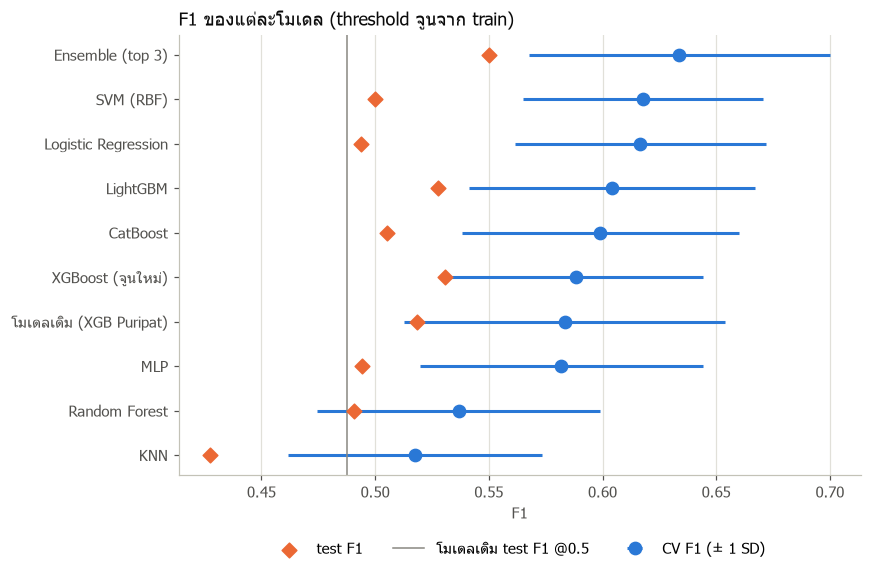

In [8]:
order = table.index[::-1]
key = {v: k for k, v in LABEL.items()}
fig, ax = plt.subplots(figsize=(8, 5.2))
yy = np.arange(len(order))
cv_m = [results[key[l]]["cv"]["f1"] for l in order]; cv_s = [results[key[l]]["cv"]["f1_sd"] for l in order]
te = [results[key[l]]["test"]["f1"] for l in order]
ax.errorbar(cv_m, yy, xerr=cv_s, fmt="o", color=C["blue"], ms=8, lw=2, capsize=0, label="CV F1 (± 1 SD)")
ax.scatter(te, yy, marker="D", s=46, color=C["orange"], zorder=3, label="test F1")
ax.axvline(results["Baseline"]["test"]["f1_at_05"], color=C["muted"], lw=1, label="โมเดลเดิม test F1 @0.5")
ax.set_yticks(yy, order); ax.set_xlabel("F1"); ax.grid(axis="y", visible=False)
ax.set_title("F1 ของแต่ละโมเดล (threshold จูนจาก train)", loc="left", color=C["ink"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
fig.savefig(f"{OUT}/01_model_f1.png"); plt.show()

**กราฟ 2:** คะแนนที่ดีขึ้นมาจากไหน — แยกผลของ "จูน threshold" ออกจากผลของ "เปลี่ยนโมเดล" (test F1)

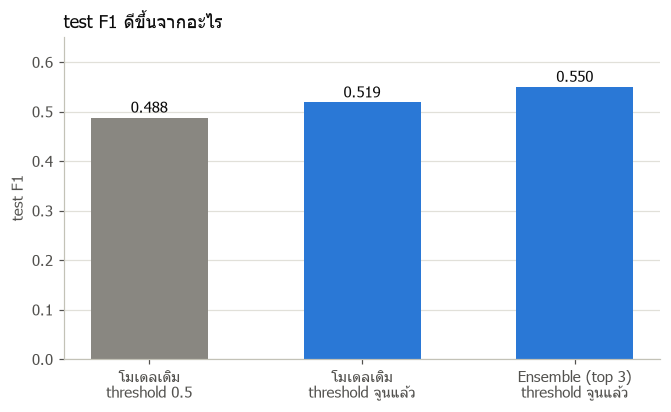

In [9]:
best = key[table.index[0]] if key[table.index[0]] != "Baseline" else key[table.index[1]]
steps = [("โมเดลเดิม\nthreshold 0.5", results["Baseline"]["test"]["f1_at_05"]),
         ("โมเดลเดิม\nthreshold จูนแล้ว", results["Baseline"]["test"]["f1"]),
         (f"{LABEL[best]}\nthreshold จูนแล้ว", results[best]["test"]["f1"])]
fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar([s[0] for s in steps], [s[1] for s in steps], color=[C["muted"], C["blue"], C["blue"]], width=0.55)
for bar, (_, v) in zip(bars, steps):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", color=C["ink"])
ax.set_ylim(0, max(s[1] for s in steps) + 0.1); ax.set_ylabel("test F1"); ax.grid(axis="x", visible=False)
ax.set_title("test F1 ดีขึ้นจากอะไร", loc="left", color=C["ink"])
fig.savefig(f"{OUT}/02_f1_gain.png"); plt.show()

**กราฟ 3:** Precision-Recall curve บน test ของ 3 โมเดลที่ดีที่สุดเทียบโมเดลเดิม
เส้นที่อยู่สูงและขวากว่า = จับคนลาออกได้มากโดยทักผิดน้อยกว่า

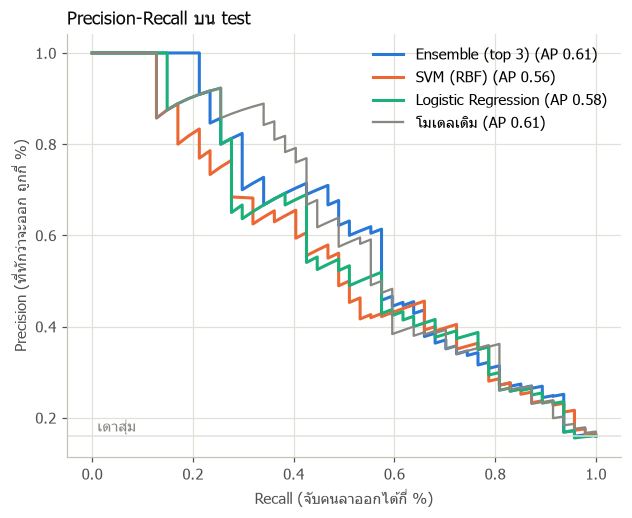

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5))
show = [k for k in [key[l] for l in table.index] if k != "Baseline"][:3]
for k, col in zip(show, [C["blue"], C["orange"], C["aqua"]]):
    pr, rc, _ = precision_recall_curve(yte, test_proba[k]); ax.plot(rc, pr, color=col, lw=2, label=f"{LABEL[k]} (AP {results[k]['test']['pr_auc']:.2f})")
pr, rc, _ = precision_recall_curve(yte, test_proba["Baseline"]); ax.plot(rc, pr, color=C["muted"], lw=1.5, label=f"โมเดลเดิม (AP {results['Baseline']['test']['pr_auc']:.2f})")
ax.axhline(yte.mean(), color=C["grid"], lw=1); ax.text(0.01, yte.mean() + 0.01, "เดาสุ่ม", color=C["muted"])
ax.set_xlabel("Recall (จับคนลาออกได้กี่ %)"); ax.set_ylabel("Precision (ที่ทักว่าจะออก ถูกกี่ %)")
ax.set_title("Precision-Recall บน test", loc="left", color=C["ink"]); ax.legend(frameon=False)
fig.savefig(f"{OUT}/03_pr_curves.png"); plt.show()

## 8. บันทึกผล: MLflow (1 run ต่อโมเดล) + `results.json`

แต่ละ run มี params, threshold, คะแนน CV/test, tag บอกเจ้าของและ git commit และแนบตารางทุก trial เป็น `trials.csv`
ถ้าต่อ MLflow ไม่ได้ notebook ยังรันต่อได้ เพราะตัวเลขทั้งหมดอยู่ใน `results.json` ด้วยอยู่แล้ว

In [11]:
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
try:
    print("MLflow:", mlflow_setup.setup("attrition-model-lab-S"))
    for name, r in results.items():
        with mlflow.start_run(run_name=f"lab-{name}"):
            mlflow.set_tags({"author": "Saphondanai", "stage": "experiment", "git_commit": commit, "model": name})
            mlflow.log_params({k: str(v) for k, v in r["params"].items()} | {"threshold": round(r["cv"]["threshold"], 4)})
            mlflow.log_metrics({"cv_f1": r["cv"]["f1"], "cv_f1_sd": r["cv"]["f1_sd"], "cv_pr_auc": r["cv"]["pr_auc"],
                                **{f"test_{k}": v for k, v in r["test"].items() if k != "cm"}})
            if r["trials"]:
                path = f"{OUT}/trials_{name}.csv"; pd.DataFrame(r["trials"]).to_csv(path, index=False)
                mlflow.log_artifact(path); os.remove(path)
    print("log ครบ", len(results), "runs")
except Exception as e:
    print("⚠ log MLflow ไม่สำเร็จ (ผลยังอยู่ใน results.json):", e)

def clean(v):
    return [round(float(x), 4) for x in v]
export = {"meta": {"git_commit": commit, "n_train": len(ytr), "n_test": len(yte), "positive_rate": round(float(ytr.mean()), 4),
                   "cv": "RepeatedStratifiedKFold 5x2", "trials_per_model": N_TRIALS, "n_features": X.shape[1]},
          "labels": LABEL, "models": {}, "y_train": ytr.astype(int).tolist(), "y_test": yte.astype(int).tolist()}
for name, r in results.items():
    export["models"][name] = {"params": r["params"], "seconds": r["seconds"], "trials": r["trials"], "test": r["test"],
                              "cv": {k: (clean(v) if k in ("oof", "fold_f1") else v) for k, v in r["cv"].items()},
                              "test_proba": clean(test_proba[name])}
json.dump(export, open(f"{OUT}/results.json", "w", encoding="utf-8"), ensure_ascii=False, default=str)
print("saved", f"{OUT}/results.json")

2026/09/30 15:15:41 INFO mlflow.tracking.fluent: Experiment with name 'attrition-model-lab-S' does not exist. Creating a new experiment.


MLflow: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow


🏃 View run lab-LogReg at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/3778a3b644c542a4a6f25df60019b5fe
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-RandomForest at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/c94ef8ad82e54b21baeac018d22c2c25
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-SVM at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/816333134810410f9e44fbd312239048
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


...

🏃 View run lab-LightGBM at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/4e0c8acd9581439aa0012f505047b997
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-CatBoost at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/e49f602682b64706a319396fc3f02d2d
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-Ensemble at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/da12cb8106ae4d038f822699df702612
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-Baseline at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/d499238a55b0410381f66721f835763e
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


log ครบ 10 runs
saved ../docs/model_lab_S/results.json


## 9. สรุป

**ผล (F1 บน test, threshold ตรึงจาก train):**

| | test F1 | เพิ่มจากเดิม |
| :--- | ---: | ---: |
| โมเดลเดิม (XGB Puripat), threshold 0.5 ที่ใช้อยู่ | 0.488 | |
| โมเดลเดิม, จูน threshold เป็น 0.66 | 0.519 | +0.031 |
| Ensemble (SVM + LogReg + LightGBM), threshold 0.56 | 0.550 | +0.062 |

- Ensemble ดีที่สุดทั้ง CV แบบ nested (0.632, ดู 06 หัวข้อ 0) และ test แต่ส่วนต่างกับโมเดลเดิมที่จูน threshold แล้ว (+0.031) ยังเล็กกว่าความแกว่งระหว่าง fold (SD ~0.07)
- โมเดลเส้นตรง (LogReg, SVM) ได้ CV ใกล้ boosting แสดงว่าความสัมพันธ์ในข้อมูลชุดนี้ไม่ซับซ้อน สอดคล้องกับที่ boosting ทุกตัวเลือกต้นไม้ลึกแค่ 1–2 ชั้น
- KNN และ Random Forest อ่อนสุด ไม่ควรใช้ต่อ
- test ต่ำกว่า CV ทุกโมเดล (เฉลี่ย 0.084) ส่วนหนึ่ง (~0.02) มาจากการเลือก threshold บนข้อมูลชุดเดียวกับที่วัดผล ที่เหลือมาจาก test มีคนลาออกแค่ 47 คน

**ข้อเสนอต่อทีม:**
1. **ทำก่อน:** ใช้โมเดลเดิมต่อ แต่จูน threshold ตัดสิน "เสี่ยงลาออก" จาก 0.5 เป็นค่าที่ได้จาก OOF (0.66) ได้ F1 เพิ่ม +0.031 โดย backend, SHAP (`TreeExplainer`) และ recalibration ไม่ต้องเปลี่ยน ต้องตกลงกับทีมว่าจะผูก threshold นี้กับ Risk Banding (README 6.1) อย่างไร
2. **ทางเลือกถัดไป:** Ensemble (SVM + LogReg + LightGBM) ได้ F1 สูงสุด แต่ `/shap` ต้องเปลี่ยนจาก `TreeExplainer` เป็นวิธีที่ใช้ได้กับทุกโมเดล (เช่น KernelExplainer ช้ากว่ามาก หรืออธิบายด้วยโมเดลสมาชิกตัวเดียว) ควรตัดสินใจร่วมกับ Puripat ก่อน
3. ถ้าจะทดลองต่อ ให้เก็บข้อมูลเพิ่ม/ใช้ test ที่ใหญ่ขึ้นก่อน เพราะตอนนี้ความต่างระดับ 0.03 ยังแยกไม่ออกจาก noise

---
**ที่มาของข้อมูล:** IBM HR Analytics Employee Attrition & Performance ([Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)) ข้อมูลสมมติที่สร้างโดย IBM data scientists ใช้ภายใต้ [ODbL v1.0](https://opendatacommons.org/licenses/odbl/1-0/) / [DbCL v1.0](https://opendatacommons.org/licenses/dbcl/1-0/) ดูรายละเอียดที่ [docs/dataset.md](../docs/dataset.md)